# **Procesamiento de Lenguaje Natural**: representaciones vectoriales de palabras y oraciones mediante word y text embeddings.


**Pablo Martínez Olmos, Angel Navia Vázquez**

  * 1.1 (January 2026) Revised and updated version

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />

# 1 - Embeddings

Un **"embedding"** es una **representación vectorial** de nuestros datos en un espacio de **dimensión relativamente baja**. Todas las variantes se basan en un principio básico:

**`Conceptualmente, si dos palabras son similares, deberían tener valores similares en este espacio vectorial proyectado`**

La representación mediante *embeddings* suele utilizarse para **facilitar el aprendizaje de modelos** cuando se tienen que manejar datos categóricos o conceptos cuya codificación suele llevar a representaciones *sparse* de **alta dimensión**, como pueden ser codificaciones one-hot encoding de variables categóricas estandar o  representaciones BoW/TF-IDF de documentos (recordemos el problema de "maldición de la dimensionalidad").

Así, por ejemplo, una codificación **one-hot** de diferentes palabras nos llevaría a vectores de este tipo:

<img src="http://www.tsc.uc3m.es/~navia/figures/OneHotEncodingv3.png" width="35%">




Al utilizar este tipo de representaciones en un sistema de aprendizaje automático nos encontramos varias limitaciones:

* Por un lado, trabajar con un espacio de **muy alta dimensión** (los vectores tendrían tantas dimensiones como palabras diferentes en el vocabulario) implica entrenar un modelo con muchos parámetros, lo que a su vez conlleva un mayor **coste computacional** o **riesgo de sobreajuste**.

* Por otro lado, manejar representaciones dispersas dificulta el **cálculo de distancias** entre elementos así como la **identificación de elementos similares**. Por ejemplo, la codificación anterior nos va a dar la misma distancia entre "Roma" y "pera" que entre "pera" y "manzana", o entre "coche" y "automóvil".

Por tanto, para utilizar este tipo de codificaciones en un sistema de aprendizaje automático, necesitamos una forma de representar cada vector disperso como un **vector de números en el que los elementos semánticamente similares** (ciudades, películas o palabras) **tengan distancias similares en el espacio vectorial**. La solución a estos problemas es utilizar **embeddings**, ya que son capaces de transformar grandes vectores dispersos ("one-hot encoding") a un **espacio de menor dimensión que preserva las relaciones semánticas**.

Nótese que la ya conocida técnica de **Latent Semantic Analysis (LSA)** nos permitía obtener representaciones en espacios de dimensión reducida $K$, pero el tratamiento que recibían todas las entradas era similar, **no se hacía distinción semántica entre palabras**.

Idealmente, un buen *embedding* debe proporcionar un conjunto de vectores cuya posición (distancia y dirección) en el espacio vectorial **codifique la semántica de los datos** que representan. Las siguientes [visualizaciones](https://developers.google.com/machine-learning/crash-course/embeddings/translating-to-a-lower-dimensional-space) de *embeddings* reales muestran relaciones geométricas que capturan relaciones semánticas como el genero, un tiempo verbal o la relación entre un país y su capital

<img src="http://www.tsc.uc3m.es/~navia/figures/Embeddings1.svg" width="80%">


Además, la representación de los datos mediante  **embeddings** tiene varias **ventajas**:
* Ayuda al aprendizaje del modelo, ya que **reducirá el coste computacional y evitará problemas de sobreajuste**.  
* Esta representación puede aprenderse y **reutilizarse** en distintos modelos basados en el mismo espacio de entrada (por ejemplo, texto). **Muchas librerias, como Gensim o Spacy, proporcionan embeddings ya preentrenados**.
* Al manejar los **datos en un espacio de baja dimensión** se **facilita su representación**, ya sea porque el *embedding* nos permite tener los datos en un espacio de dos o tres dimensiones, o porque se puede combinar con **algoritmos de visualización** que nos permiten comprender lo que está ocurriendo en este espacio del *embedding*.


En la sesión de hoy, estudiaremos aspectos relacionados con **embeddings** de texto, o **transformaciones** de las representaciones de los textos en **espacios de dimensión reducida** que preservan el **contexto** entre palabras.

Una de las aproximaciones más populares es el modelo **Word2Vec**. Concretamente en este tema revisaremos:

- **Entrenamiento de Word2Vec** con Gensim.

- **Modelos Word2Vec pre-entrenados** en Gensim y spaCy.




Al final de tema también veremos:

- **otros modelos** de embeddings: **CBoW, GloVe, FastText**.

- **Uso de modelos pre-entrenados**.

- **Text embeddings (embeddings para documentos)**  con **Doc2Vec** y Gensim.

# 2 - Embeddings de palabras con Word2Vec

[Word2vec](https://arxiv.org/pdf/1310.4546.pdf) utiliza un tipo muy sencillo de **red neuronal** para aprender asociaciones de palabras de un gran corpus de texto. Se basa en la premisa de que **palabras con significado similar deben ser codificadas con vectores cercanos en un espacio vectorial**. Para ello se considera que las palabras que suelen tener las mismas palabras vecinas (**contexto**) tienden a ser semánticamente similares. *Por ejemplo, tanto "perro" como "gato" aparecen con frecuencia cerca de la palabra "veterinario", y este hecho refleja su similitud semántica*.

Si bien en general vamos a utilizar librerías y modelos pre-entrenados, explicaremos el **funcionamiento detallado de Word2vec** como ejemplo representativo de modelo de red neuronal aplicado a NLP. Para ello, revisamos brevemente el modelo ya conocido de **regresión logística para clasificación** y su extensión a Wor2Vec.

Hay diferentes esquemas para construir un word2vec, aquí vamos a ver el modelo más común que es el **Skip-Gram**: **Dada una palabra, ¿podemos predecir las palabras vecinas en un corpus de texto?**



## 2.1 - Revisión: regresión logística binaria

Supongamos que tenemos un conjunto de datos de entrenamiento $(\mathbf{x}_i,y_i)$ donde $\mathbf{x}_i\in\mathbf{R}^m$ e $y_i\in\{0,1\}$.


En regresión logística (en adelante LR) aproximamos la probabilidad de la etiqueta $y$ usando una **combinación lineal** de las entradas $\bf x$:

$$P(y=1| {\bf x}) =  \frac{1}{1+\exp(-({\bf w}^T {\bf x}+w_0))}=\sigma({\bf w}^T {\bf x}+w_0)$$
$$$$
$$ P(y=0| {\bf x}) = 1- P(Y=y| {\bf x}) = 1 - \sigma({\bf w}^T {\bf x}+w_0)$$

donde

- $w_0$ y ${\bf w} = [w_1, \ldots, w_D]$ son parámetros que aprenderemos usando el conjunto de datos de entrenamiento $(\mathbf{x}^{(i)},y^{(i)})_{i=1,\ldots,N}$.
$$$$
- $\sigma(a) = \frac{1}{1+\exp(-a)}$ es la función sigmoide.
$$$$

Para encontrar los pesos del modelo $\mathbf{w}$), LR resuelve el siguiente problema de optimización (entropía cruzada, eng. "cross-entropy"):

$$l({\bf w}) = -\sum_{i=1}^N \left\lbrace  y^{(i)}\log \left(  P(y=1| {\bf x}^{(i)})\right)  + (1-y^{(i)}) \log\left(  1- P(y=1| {\bf x}^{(i)}) \right)  \right\rbrace $$

$${\bf w}^* =\displaystyle \underset{{\bf w}}{\operatorname{min}} l({\bf w})$$

- Que no es más que intentar alinear las estimaciones de probabilidades con **las etiquetas reales**.
- Este problema no tiene solución cerrada. Se resuelve con optimización numérica.


## 2.2 - Regresión logística multiclase (ing. MLR)

Supongamos ahora que tenemos etiquetas con $K$ posibles valores: $y_i \in\{1,\ldots,K\}$. La LR se formula ahora utilizando la función "**softmax**", una generalización de la función logística:

\begin{align}
P(y=k|\mathbf{x}) = \frac{\text{e}^{z_k}}{\sum_{j=1}^{K}\text{e}^{z_j}}, k =1,\ldots,K
\end{align}
donde el vector $\mathbf{z} = \left[z_1,\ldots,z_K\right]$ se calcula como

$$\mathbf{z} = \mathbf{W}\mathbf{x} + \mathbf{w}_0$$

siendo $\mathbf{W}$ una matriz real de dimensiones $K\times m$ y $\mathbf{w_0}$ un vector de dimensiones $K \times 1$.

Veamos un **ejemplo gráfico de la función softmax**, en un ejemplo con tres clases y entrada unidimensional. Representaremos en primer lugar los valores de $z_k$ en función de $x$:

<center>
<img src="http://www.tsc.uc3m.es/~navia/figures/softmax1.PNG" width="40%">
</center>

Podemos ver claramente las **tres regiones de decisión en las que se divide el eje x**, dependiendo del valor de cada variable $z_k$. **La función softmax nos ayuda a identificar dichas regiones**, obteniendo directamente la **estimación de la probabilidad de cada clase** $P(y=k|\mathbf{x})$, $k=1, 2,3$:

<center>
<img src="http://www.tsc.uc3m.es/~navia/figures/softmax2.PNG" width="40%">
</center>

En un caso general, con datos de entrenamiento, debemos estimar el valor óptimo de los pesos del modelo. La **función de coste** en MLR es análoga al caso binario, pues acumulamos el **negativo del logaritmo de la probabilidad** que damos a cada etiqueta real:

$$l({\bf W,w_0}) = - \sum_{i=1}^N \sum_{j=1}^{K} \log \left(  P(Y=k| {\bf x}^{(i)})\right) \mathbb{\phi}[y^{(i)}==k]$$


donde $\mathbb{\phi}[y^{(i)}==k]$ toma valor $1$ si el valor de $y^{(i)}$ es $k$ y cero en otro caso. Dichos términos en el sumatorio tomarán valor mínimo cuando la probabilidad de cada clase sea máxima, ya que la función $f(P) = -log(P)$ tiende a 0 cuando P tiende a 1, $f(P)$ tiende a infinito cuando $P$ tiende a cero.

La **optimización** del coste se obtiene mediante la minimización del funcional $l({\bf W,w_0})$ con respecto a los pesos del modelo:


$${\bf W^*,w^*_0} =\displaystyle \underset{{\bf W,w_0}}{\operatorname{min}} l({\bf W,w_0})$$

## 2.3 - Modelo Skip-Gram

El modelo **Skip-gram** es uno de los más sencillos utilizado para obtener **embeddings de datos de alta dimensión**, concretamente en este caso, para textos.

Supongamos que se tiene una **ventana deslizante que se desplaza a lo largo de una frase**: consideraremos la palabra **central** (en el centro de la ventana), así como las que están a su izquierda y derecha dentro de la ventana deslizante, denominadas palabras de **contexto**.

En el siguiente ejemplo usamos una **ventana de tamaño 5** (**palabra central, dos a la izquierda y dos a la derecha**) para ir construyendo nuestras muestras de entrenamiento con **pares de palabras (central, contexto)**.

**Nota**: dependiendo de la posición de la palabra "central" en la frase, puede no haber palabras a izquierda o derecha.




Veamos a continuación todos los **pares de entrenamiento (central, contexto)** que se obtienen:

<img src="http://www.tsc.uc3m.es/~navia/figures/word2vec1.png" width="80%">


La estructura final del **modelo Skip-Gram**, que mostramos a continuación, es un tipo de **red neuronal** de dos capas:

<center>
<img src="http://www.tsc.uc3m.es/~navia/figures/Skipgram.png" width="70%">
</center>


- Las **palabras centrales** ($x_1$, ..., $x_v$) están a la **entrada de la red con una codificación one-hot**. Las palabras **contexto** ($y_1$, ..., $y_v$) están a la **salida también con una codificación one-hot**. De este modo la red, **para cada para palabra central, debe predecir el contexto**. Pero este **NO** es el **objetivo principal de la red**...

- La **primera capa** pretende transformar las entradas de dimensión $V$ en una **representación de menor dimensión $D$**. El tamaño de esta capa **($D$) define el tamaño o dimensión de nuestro embedding**; para procesado de texto suelen usarse embedding de tamaño 100, 200,... aunque lógicamente esto depende de la complejidad de la base de datos. Los pesos de esta primera capa definen lo que se conoce como "**embedding matrix**". Alcanzar un **buen embedding** en esta capa **SI es el objetivo principal**.

- La **segunda capa** es la que implementa la **regresión logística multiclase** para **predecir las palabras de contexto a partir del embedding**. Los pesos de esta segunda capa se denominan "**context matrix**".

- como todo el modelo se **entrena conjuntamente**, se onbtendrán **buenas prestaciones en la capa de salida** cuando en la **primera capa** se obtenga un **buen embedding** que represente adecuadamente el contexto de las palabras.


A partir de este conjunto de datos, **el modelo Skip-Gram se entrena para predecir las probabilidades de que una palabra sea el contexto de una determinada palabra central**. Para ello utiliza una **regresión logística multiclase, MLR**.

Si utilizáramos **directamente la codificación one-hot** de las palabras tanto en la entrada como en la salida, tendríamos una **red con $V^2$ parámetros**. Por ejemplo, si tenemos un diccionario de 2.000 palabras, tendríamos 4 millones de pesos a ajustar, y habría una solución trivial que no nos interesa (matriz identidad).

En el modelo Skip-gram se utiliza una **capa intermedia de $D$ elementos (neuronas lineales)**, a fin de reducir la dimensionalidad de la representación (de forma análoga al caso de LSA utilizando únicamente k conceptos), y una **capa final con $V$ neuronas softmax**. Por ejemplo,asumiendo un valor $D=300$ para el embedding, tendríamos un total de pesos de ($V \times D$) en la primera capa y de ($D \times V$) en la segunda, es decir, 1.200.000 pesos, un $30\%$ de los pesos en el caso anterior. **La ganancia (compactación) es mayor cuanto mayor sea el vocabulario**. Por ejemplo, con un vocabulario de $20.000$ palabras, sólo necesitariamos un $3\%$ de los pesos.




De este modo, vemos que **la entrada al clasificador (segunda capa del modelo Skipgram) no es directamente la codificación one-hot** de cada palabra, sino un vector real de dimensión $D<<V$ que se aprende junto a los parámetros de la regresión logística. **Este vector de dimensión $D$ será el "word embedding" de dicha palabra**.


Al introducir la capa de dimensión reducida, **reducimos también el número de parámetros libres en el modelo**, como hemos visto anteriormente, lo que fuerza a compactar la información de contexto.



Usando el conjunto de entrenamiento que generamos con el corpus de datos, podremos entrenar la red y se aprenderán las matrices de entrada **$W$** y la de salida **$W'$**. Mientras que la matriz de salida codifica el contexto, la matriz de entrada (denominada *embedding*) nos da una **representación en un espacio de tamaño $D$ de cada una de las palabras** en nuestro corpus.

**Nota:** **$W$** y **$W'$** son dos matrices distintas, **$W'$** no significa traspuesto de **$W$**.

## 2.4 - Uso de Word Embeddings pre-entrenados en spaCy

Los distintos pipelines accesibles a través de spaCy se pueden consultar [aquí](https://spacy.io/models/en). Muchos de ellos incluyen word embeddings pre-entrenados. Los principales que utilizaremos son:

- **`en_core_web_sm`** (small)

- **`en_core_web_md`** (medium)

- **`en_core_web_lg`** (large)



Podemos acceder de forma sencilla al **word embedding de cada palabra** utilizando el **atributo "``vector``" proporcionado por Spacy**. Adicionalmente podemos comprobar previamente si se dispone del vector (``has_vector``), la norma de dicho vector (``vector_norm``) o si está fuera del vocabulario (``is_oov``).

In [ ]:
# Ejecutamos este código para preparar el contexto.
%matplotlib inline
# Figures plotted inside the notebook
%config InlineBackend.figure_format = 'retina'
# High quality figures
import matplotlib.pyplot as plt
# Configuración de las figuras matplotlib
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams.update({'font.size': 12})

In [ ]:
# Estas librerías pueden dar problemas de dependencias, conviene instalarlas conjuntamente, para que pip resuelva correctamente las dependencias
!pip install --upgrade numpy pandas scipy gensim spacy nltk

In [ ]:
import numpy as np
import scipy
import pandas as pd
import spacy
import gensim
import nltk

print(f"NumPy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Spacy version: {spacy.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")

# 2025
# NumPy version: 1.26.4
# Scipy version: 1.13.1
# Pandas version: 2.2.3
# Spacy version: 3.8.4
# Gensim version: 4.3.3
# NLTK version: 3.9.1

# 2026
# NumPy version: 2.4.2
# Scipy version: 1.17.0
# Pandas version: 3.0.0
# Spacy version: 3.8.11
# Gensim version: 4.4.0
# NLTK version: 3.9.2

NumPy version: 2.4.2
Scipy version: 1.17.0
Pandas version: 3.0.0
Spacy version: 3.8.11
Gensim version: 4.4.0
NLTK version: 3.9.2


In [ ]:
import gc
import time
!pip install tqdm
from tqdm import tqdm
import time
import random
import seaborn as sns

In [ ]:
# Descargamos uno de los modelos Spacy que contiene embeddings
# Los aquí indicados tienen estas dimensiones de embedding, podemos elegir uno u otro

# Dimensión embedding = 96
#!python -m spacy download en_core_web_sm  #Small
#nlp = spacy.load('en_core_web_sm')

# Dimensión embedding = 300
#!python -m spacy download en_core_web_md  # Medium
#nlp = spacy.load('en_core_web_md')

# Dimensión embedding = 300
!python -m spacy download en_core_web_lg # Large
nlp = spacy.load('en_core_web_lg')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.7/400.7 MB 3.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
tokens = nlp("This is a great course")

details_embedding = [[token.text, token.has_vector, token.vector_norm, token.is_oov, len(token.vector)] for token in tokens]

df = pd.DataFrame(details_embedding, columns=['Word','Has Vector','Vector Norm', 'Is OOV', "Vector size"])
df.style.set_properties(**{'text-align': 'left'})


,Word,Has Vector,Vector Norm,Is OOV,Vector size
0,This,True,5.046126,False,300
1,is,True,4.890306,False,300
2,a,True,5.306696,False,300
3,great,True,5.439593,False,300
4,course,True,5.332495,False,300


Vemos que los modelos de embedding de Spacy tienen una dimensión (**$D$**) de **96 o 300**, es decir, cada palabra se traduce en un vector con 96 o 300 valores numéricos, según el modelo Spacy elegido (**Small, Medium, Large**). Por ejemplo, para la primera palabra, éste sería el embedding:

In [ ]:
print(tokens[0].vector)

[-8.7595e-02  3.5502e-01  6.3868e-02  2.9292e-01 -2.3635e-01 -6.2773e-02
 -1.6105e-01 -2.2842e-01  4.1587e-02  2.4844e+00 -3.8217e-01  3.2806e-02
  1.2348e-01 -1.8422e-03 -1.3848e-01 -1.0005e-03 -4.3081e-02  1.1659e+00
 -4.7327e-02 -5.6004e-02  1.5617e-01 -1.3394e-01  2.3229e-01  8.7602e-02
 -3.2329e-01  1.6721e-01 -1.6221e-01 -9.1919e-02 -3.8004e-01  1.2686e-01
  6.7819e-02  3.2509e-01 -5.7245e-02 -3.2630e-01 -1.1903e-01 -6.3964e-04
 -5.9275e-03 -2.9934e-01 -8.5043e-02 -2.6683e-01 -1.5815e-01  2.5963e-01
  2.2571e-01  6.2582e-02 -1.9394e-01  2.1922e-01 -3.1186e-01  3.7084e-01
 -3.6577e-01 -5.2483e-02 -4.3101e-01  1.2379e-01  1.5529e-02 -1.2505e-01
  2.2327e-01  2.9365e-01 -8.5104e-03 -8.3909e-02  2.4078e-01 -3.4913e-01
 -2.8355e-01 -7.6594e-02 -1.7130e-01  3.2869e-01  2.9024e-01 -6.2741e-02
 -5.5278e-02 -2.8706e-01  7.9608e-02  1.3234e-01  4.7857e-01  1.9623e-01
  2.7314e-01 -1.3089e-01  2.7630e-01 -8.8846e-02 -1.2379e-01  7.3987e-02
 -5.1962e-01  3.5227e-01 -2.9182e-02  1.6203e-01 -3

### Ejercicio:

Utilizando estos embeddings, calcule las distancias o similitudes entre las palabras del ejemplo de la introducción (en inglés): Rome, Paris, pear, apple, car, vehicle.

In [ ]:
palabras = <INSERT CODE HERE>
palabras_spacy = <INSERT CODE HERE>
Npalabras = len(palabras)

for m in range(Npalabras):
  print('=' * 50)
  for n in range(Npalabras):
    distancia = <INSERT CODE HERE>
    print(f"Distancia entre {palabras[m]} y {palabras[n]}: {distancia}")


### Solución

In [ ]:
palabras = ["Rome", "Paris", "pear", "apple", "car", "vehicle"]

palabras_spacy = [nlp(palabra) for palabra in palabras]
Npalabras = len(palabras)

for m in range(Npalabras):
  print('=' * 50)
  for n in range(Npalabras):
    embedd1 = palabras_spacy[m].vector
    embedd2 = palabras_spacy[n].vector
    distancia = np.linalg.norm(embedd1 - embedd2)
    print(f"Distancia entre {palabras[m]} y {palabras[n]}: {distancia}")


Distancia entre Rome y Rome: 0.0
Distancia entre Rome y Paris: 6.4753828048706055
Distancia entre Rome y pear: 9.881524085998535
Distancia entre Rome y apple: 9.016512870788574
Distancia entre Rome y car: 9.177122116088867
Distancia entre Rome y vehicle: 9.746562957763672
Distancia entre Paris y Rome: 6.4753828048706055
Distancia entre Paris y Paris: 0.0
Distancia entre Paris y pear: 9.342706680297852
Distancia entre Paris y apple: 8.56678295135498
Distancia entre Paris y car: 8.528070449829102
Distancia entre Paris y vehicle: 9.668773651123047
Distancia entre pear y Rome: 9.881524085998535
Distancia entre pear y Paris: 9.342706680297852
Distancia entre pear y pear: 0.0
Distancia entre pear y apple: 6.289800643920898
Distancia entre pear y car: 9.909875869750977
Distancia entre pear y vehicle: 10.096582412719727
Distancia entre apple y Rome: 9.016512870788574
Distancia entre apple y Paris: 8.56678295135498
Distancia entre apple y pear: 6.289800643920898
Distancia entre apple y apple: 0

Para probar los word embeddings vamos a utilizar uno de los datasets de NLTK. En este caso elegimos el dataset **Reuters Corpus** que contiene **10.877 noticias sobre finanzas** y un total de 1.3 millones de palabras. Los **documentos están clasificados en 90 categorías**.

In [ ]:
from nltk.corpus import reuters

# download all dependencies and corpora
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('maxent_ne_chunker')
nltk.download('words')
nltk.download('reuters')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package maxent_ne_chunker to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping chunkers/maxent_ne_chunker.zip.
[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Unzipping corpora/words.zip.
[nltk_data] Downloading package reuters to /root/nltk_data...


True

In [ ]:
# En google colab hay que descomprimir el paquete reuters, pero sólo una vez.
# NOTA: Si ya se ha hecho con anterioridad, responder "N" en la ventana (None).
!unzip /root/nltk_data/corpora/reuters.zip -d /root/nltk_data/corpora

Streaming output truncated to the last 5000 lines.
  inflating: /root/nltk_data/corpora/reuters/training/2231  
  inflating: /root/nltk_data/corpora/reuters/training/2232  
  inflating: /root/nltk_data/corpora/reuters/training/2234  
  inflating: /root/nltk_data/corpora/reuters/training/2236  
  inflating: /root/nltk_data/corpora/reuters/training/2237  
  inflating: /root/nltk_data/corpora/reuters/training/2238  
  inflating: /root/nltk_data/corpora/reuters/training/2239  
  inflating: /root/nltk_data/corpora/reuters/training/2240  
  inflating: /root/nltk_data/corpora/reuters/training/2244  
  inflating: /root/nltk_data/corpora/reuters/training/2246  
  inflating: /root/nltk_data/corpora/reuters/training/2247  
  inflating: /root/nltk_data/corpora/reuters/training/2249  
  inflating: /root/nltk_data/corpora/reuters/training/225  
  inflating: /root/nltk_data/corpora/reuters/training/2251  
  inflating: /root/nltk_data/corpora/reuters/training/2252  
  inflating: /root/nltk_data/corpor

Veamos las categorías disponibles y el número de textos que tienen esa etiqueta:

In [ ]:
categorias = reuters.categories()
print("Estas son las categorías de los textos y el número de textos en cada una:")
for cat in categorias:
  print(cat, len(reuters.fileids(cat)))

Estas son las categorías de los textos y el número de textos en cada una:
acq 2369
alum 58
barley 51
bop 105
carcass 68
castor-oil 2
cocoa 73
coconut 6
coconut-oil 7
coffee 139
copper 65
copra-cake 3
corn 237
cotton 59
cotton-oil 3
cpi 97
cpu 4
crude 578
dfl 3
dlr 175
dmk 14
earn 3964
fuel 23
gas 54
gnp 136
gold 124
grain 582
groundnut 9
groundnut-oil 2
heat 19
hog 22
housing 20
income 16
instal-debt 6
interest 478
ipi 53
iron-steel 54
jet 5
jobs 67
l-cattle 8
lead 29
lei 15
lin-oil 2
livestock 99
lumber 16
meal-feed 49
money-fx 717
money-supply 174
naphtha 6
nat-gas 105
nickel 9
nkr 3
nzdlr 4
oat 14
oilseed 171
orange 27
palladium 3
palm-oil 40
palmkernel 3
pet-chem 32
platinum 12
potato 6
propane 6
rand 3
rape-oil 8
rapeseed 27
reserves 73
retail 25
rice 59
rubber 49
rye 2
ship 286
silver 29
sorghum 34
soy-meal 26
soy-oil 25
soybean 111
strategic-metal 27
sugar 162
sun-meal 2
sun-oil 7
sunseed 16
tea 13
tin 30
trade 485
veg-oil 124
wheat 283
wpi 29
yen 59
zinc 34


Vamos a quedarnos con **noticias de algunas de las categorías**, para reducir un poco el tamaño del corpus (este paso es opcional, pero los experimentos tardarán más).

In [ ]:
retener_categorias = ['alum', 'barley', 'bop', 'carcass', 'castor-oil', 'cocoa', 'coconut', 'coffee', 'copper', 'cotton', 'cpu', 'fuel', 'gas', 'gold', 'housing', 'income', 'jobs', 'livestock', 'lumber', 'nickel', 'nkr', 'nzdlr', 'oat', 'oilseed', 'orange', 'palm-oil', 'platinum', 'potato', 'rice', 'silver', 'soybean', 'sugar', 'sunseed', 'tea', 'zinc']

reuters_raw = [reuters.raw(f) for f in reuters.fileids(retener_categorias)]

In [ ]:
print(f"Hay un total de {len(reuters_raw)} documentos. El primero de ellos es:\n")

print(reuters_raw[0][0:300] , "...")

Hay un total de 1382 documentos. El primero de ellos es:

THAI TRADE DEFICIT WIDENS IN FIRST QUARTER
  Thailand's trade deficit widened to 4.5
  billion baht in the first quarter of 1987 from 2.1 billion a
  year ago, the Business Economics Department said.
      It said Janunary/March imports rose to 65.1 billion baht
  from 58.7 billion. Thailand's impro ...


A continuación vamos a **normalizar y tokenizar** el corpus, reteniendo sólo las palabras no numéricas y eliminando las stop words:

In [ ]:
reuters_tokens_string = [[w.text.lower() for w in nlp(d) if not w.is_stop
                  and not w.is_punct and w.is_alpha] for d in reuters_raw]

In [ ]:
print("\nEl corpus reuters_tokens_string contiene {} documentos.".format(len(reuters_tokens_string)))

print("\nCada documento en reuters_tokens_string es una lista de tokens tipo 'string':")
print(reuters_tokens_string[0][0:10])
print(type(reuters_tokens_string[0][0]))


El corpus reuters_tokens_string contiene 1382 documentos.

Cada documento en reuters_tokens_string es una lista de tokens tipo 'string':
['thai', 'trade', 'deficit', 'widens', 'quarter', 'thailand', 'trade', 'deficit', 'widened', 'billion']
<class 'str'>


Vamos a utilizar los **embeddings de Spacy para buscar palabras más cercanas** en dicho espacio.


### Ejercicio: reducción de vocabulario

Reduzca el vocabulario eliminando palabras que no aparezcan en al menos 3 textos y en más del 95% de los documentos y almacene dichas palabras en una lista ``vocab``.



In [ ]:
<INSERT CODE HERE>
n_tokens = <INSERT CODE HERE>

print("El diccionario completo contiene {} palabras.".format(n_tokens))

<INSERT CODE HERE>
n_tokens = <INSERT CODE HERE>
print('El diccionario tiene ahora {} palabras.'.format(n_tokens))

vocab = <INSERT CODE HERE>

### Solución

In [ ]:
D = gensim.corpora.Dictionary(reuters_tokens_string )
n_tokens = len(D)

print("El diccionario completo contiene {} palabras.".format(n_tokens))

no_below = 3 # Minimum number of DOCUMENTS to keep a term in the dictionary
no_above = .95 # Maximum proportion of DOCUMENTS in which a term can appear to be kept in the dictionary

D.filter_extremes(no_below=no_below,no_above=no_above)
n_tokens = len(D)
print('El diccionario tiene ahora {} palabras.'.format(n_tokens))

vocab = list(D.token2id.keys())

El diccionario completo contiene 10443 palabras.
El diccionario tiene ahora 4428 palabras.


### Ejercicio: localizar palabras más cercanas en el embedding

Localice las 5 palabras más cercanas en el espacio de los embeddings (distancia euclídea) a la palabra "snow". Muestre los resultados y calcule el tiempo de ejecución.

In [ ]:
# medimos el tiempo de ejecución
t_ini = time.time()

palabra_elegida = "snow"

# calculamos distancia al resto de palabras
distancias = <INSERT CODE HERE>
orden = np.argsort(distancias)

print("\nEstas son las 5 palabras más cercanas a {}:\n".format(palabra_elegida))
for k in range(5):
  print(vocab[orden[k + 1]])

print("\nLa búsqueda ha tardado {} segundos.".format(time.time() - t_ini))

### Solución

In [ ]:
# medimos el tiempo de ejecución
t_ini = time.time()

palabra_elegida = "snow"

# calculamos distancia al resto de palabras
distancias = [np.linalg.norm(nlp(palabra_elegida).vector - nlp(palabra).vector) for palabra in vocab]
orden = np.argsort(distancias)

print("\nEstas son las 5 palabras más cercanas a {}:\n".format(palabra_elegida))
for k in range(5):
  print(vocab[orden[k + 1]])

print("\nLa búsqueda ha tardado {} segundos.".format(time.time() - t_ini))


Estas son las 5 palabras más cercanas a snow:

winter
rain
storm
weather
rainy

La búsqueda ha tardado 47.968804359436035 segundos.


### Ejercicio: acelerando el proceso

Vemos que el acceso a los embeddings y el cálculo de las distancias **tarda bastante tiempo**, vamos a intentar **acelerar el proceso**:

- Construya un **diccionario que almacene los embeddings** de cada una de las palabras del vocabulario y use dicho diccionario para buscar las palabras más cercanas de forma más eficiente. Este paso sólo es necesario realizarlo una vez. Se recomienda utilizar un [ **``dictionary_comprehension``**](https://realpython.com/python-dictionary-comprehension/).

- Defina una función python que implemente dicha búsqueda (**mida el tiempo de respuesta y compárelo con el método anterior**).

- Dadas las siguientes palabras: ``snow, farm, western, november, law, oilseed, china, dollar, gold, morning``, muestre las **5 palabras más cercanas según distancia euclídea en el espacio del embedding**.


In [ ]:
# Guardamos en un diccionario los embeddings de las palabras elegidas, para mayor comodidad.
# Usaremos para ello un "dictionary comprehension":
embeddings_dict = {<INSERT CODE HERE>}

In [ ]:
def find_closest_words(<INSERT CODE HERE>):
<INSERT CODE HERE>
  return resultados


In [ ]:
palabras = <INSERT CODE HERE>
t_ini = time.time()

for palabra_elegida in palabras:
  print('=' * 20)
  resultados = <INSERT CODE HERE>

  print("\nEstas son las 5 palabras más cercanas a {}:\n".format(palabra_elegida))
  for k in range(5):
    print(resultados[k])

  print("\nLa búsqueda ha tardado {} segundos.".format(time.time() - t_ini))

### Solución

In [ ]:
# Guardamos en un diccionario los embeddings de las palabras elegidas, para mayor comodidad.
# Usaremos para ello un "dictionary comprehension":
embeddings_dict = {palabra: nlp(palabra).vector for palabra in vocab}

In [ ]:
def find_closest_words(palabra_elegida, embeddings_dict, vocab):
  # calculamos distancia al resto de palabras
  distancias = [np.linalg.norm(embeddings_dict[palabra_elegida] - embeddings_dict[palabra]) for palabra in vocab]
  orden = np.argsort(distancias)
  resultados = [vocab[orden[k + 1]] for k in range(5)]
  return resultados

In [ ]:
palabras = ["snow", "farm", "western", "november", "law", "petrol", "china", "dollar", "gold", "morning"]
t_ini = time.time()

for palabra_elegida in palabras:
  print('=' * 20)
  resultados = find_closest_words(palabra_elegida, embeddings_dict, vocab)

  print("\nEstas son las 5 palabras más cercanas a {}:\n".format(palabra_elegida))
  for k in range(5):
    print(resultados[k])

  print("\nLa búsqueda ha tardado {} segundos.".format(time.time() - t_ini))


Estas son las 5 palabras más cercanas a snow:

winter
rain
storm
weather
rainy

La búsqueda ha tardado 0.0252377986907959 segundos.

Estas son las 5 palabras más cercanas a farm:

farms
farming
farmer
farmers
livestock

La búsqueda ha tardado 0.04653501510620117 segundos.

Estas son las 5 palabras más cercanas a western:

eastern
southern
northern
southwestern
west

La búsqueda ha tardado 0.06736898422241211 segundos.

Estas son las 5 palabras más cercanas a november:

september
december
april
october
january

La búsqueda ha tardado 0.08842206001281738 segundos.

Estas son las 5 palabras más cercanas a law:

laws
legal
legislation
states
civil

La búsqueda ha tardado 0.10872030258178711 segundos.

Estas son las 5 palabras más cercanas a petrol:

gasoline
diesel
fuel
litre
unleaded

La búsqueda ha tardado 0.12923026084899902 segundos.

Estas son las 5 palabras más cercanas a china:

taiwan
chinese
asia
korea
japan

La búsqueda ha tardado 0.14990878105163574 segundos.

Estas son las 5 p

Vemos que los tiempo de ejecución se han reducido considerablemente. Las palabras encontradas reflejan una **cercanía conceptual por similitud en el contexto de uso** en los textos.

### Ejercicio: resultado con palabra aleatoria

Repita varias veces el proceso de búsqueda de la palabra más cercana, esta vez **seleccionando aleatoriamente una palabra del vocabulario**.

In [ ]:
# Elegimos palabra aleatoria del vocabulario
palabra_elegida = <INSERT CODE HERE>

resultados = find_closest_words(palabra_elegida, embeddings_dict, vocab)

print("\nEstas son las 5 palabras más cercanas a {}:\n".format(palabra_elegida))
for k in range(5):
  print(resultados[k])

### Solución

In [ ]:
# Elegimos palabra aleatoria del vocabulario
N = len(vocab)
i = random.randint(0, N)
palabra_elegida = vocab[i]

resultados = find_closest_words(palabra_elegida, embeddings_dict, vocab)

print("\nEstas son las 5 palabras más cercanas a {}:\n".format(palabra_elegida))
for k in range(5):
  print(resultados[k])


Estas son las 5 palabras más cercanas a latest:

recent
new
upcoming
news
current


# 3 - Otros modelos de embeddings

Existen otras aproximaciones a los `word embeddings`, alternativas al uso del modelo Skip-gram:

  - [**CBoW**](https://code.google.com/archive/p/word2vec/), Continuous Bag of Words, el modelo neuronal subyacente predice una palabra objetivo (central) basándose en las palabras de contexto.

<center>
<img src="http://www.tsc.uc3m.es/~navia/figures/CBoW.png" width="70%">
</center>

  - [**Glove**](https://nlp.stanford.edu/projects/glove/), "**Global Vectors for Word Representation**", se basa en **contexto global**, aprende de la coexistencia general de palabras en todo un corpus de texto. Codifica la relación de **probabilidad de coexistencia entre dos palabras** como diferencias vectoriales.

  - [**FastText**](https://fasttext.cc/), análogo a word2vec, pero trata cada palabra como si estuviera compuesta de **n-gramas de caracteres**:
  
      `apple -> “<ap”, “app”, ”appl”, ”apple”, ”apple>”, “ppl”, “pple”, ”pple>”, “ple”, ”ple>”, ”le>”`

# 4 - Embeddings de frases/textos


Con un **word embedding** como ``word2vec``, hemos obtenido representaciones vectoriales de baja dimensión **a nivel de palabra** con estructura semántica. En este último apartado presentaremos técnicas sencillas para **vectorizar textos cortos (oraciones/párrafos)**:

- **Latent Semantic Analysis**, que ya presentamos la sesión anterior.

-  **Combinaciones de word embeddings**.

## 3.1 - Revisión de Latent Semantic Analysis (LSA)

Utilizando la **descomposición SVD de la matriz TF-IDF** de **una oración dentro de un corpus**, podemos obtener una aproximación de cada oración un vector $\mathbf{g}_j, j=1,\ldots,n$ de dimensión $K$ utilizando las componentes asociadas a los 𝐾 valores singulares de mayor valor:

<img src='http://www.tsc.uc3m.es/~navia/figures/LSA.png' width=900 />

Vamos a retomar el corpus `reuters` y **calcular similitudes entre frases usando LSA**. Primero cargamos el dataset y obtenemos la matriz TF-IDF de frases siguiendo el pipeline habitual.

### Ejercicio: procesando frases

A fin de obtener la matriz TFIDF de frases necesitamos **normalizar los textos, segmentarlos en frases y obtener el correspondiente BOW**. Vamos a procesar en primer lugar con Spacy cada uno de los documentos en ``reuters_raw``, y guardamos el resultado en otra lista ``spacy_docs`` (cada fila de spacy_docs será un elemento tipo Spacy Doc ".

Vamos a **extraer de los documentos todas las frases que al menos tienen 10 palabras** y almacenar la información resultante en varias listas:

 - **``lista_frases_spacy_tokens``** contiene las frases con tipo ``spacy.tokens.span.Span`` (resultado del segmentador en frases de Spacy).

 - **``lista_frases_text``** contiene las frases en una única cadena tipo ``string``.

 - **``lista_frases_spacy_doc``** contiene las frases convertidas a tipo ``Spacy Doc``.

### Tarea

Procesar todo el corpus Reuters con Spacy, segmentar en frases y almacenar todas ellas en una única lista. **Nota**: el tipo resultante de cada frase debe ser `spacy.tokens.span.Span`.

In [ ]:
print("Reuters_raw contiene {} documentos sin preprocesar".format(len(reuters_raw)))

# Procesamos cada documento por separado
spacy_docs = <INSERT CODE HERE>

print("Cada elemento de `spacy_docs` es de tipo {}".format(type(spacy_docs[0])))

In [ ]:
lista_frases_spacy = <INSERT CODE HERE>
Nfrases = len(lista_frases_spacy)

print("lista_frases_spacy contiene {} frases, cada una de tipo {}".format(Nfrases, type(lista_frases_spacy[0])))
print("\nEsta es una de las frases:\n")
print(type(lista_frases_spacy[25]))
print(lista_frases_spacy[25])

### Solución

In [ ]:
print("Reuters_raw contiene {} documentos sin preprocesar".format(len(reuters_raw)))

# Procesamos cada documento por separado
spacy_docs = [nlp(document) for document in reuters_raw]

print("Cada elemento de `spacy_docs` es de tipo {}".format(type(spacy_docs[0])))

Reuters_raw contiene 1382 documentos sin preprocesar
Cada elemento de `spacy_docs` es de tipo <class 'spacy.tokens.doc.Doc'>


In [ ]:
lista_frases_spacy = [s for doc in spacy_docs for s in doc.sents if len(s)>9]
Nfrases = len(lista_frases_spacy)

print("lista_frases_spacy contiene {} frases, cada una de tipo {}".format(Nfrases, type(lista_frases_spacy[0])))
print("\nEsta es una de las frases:\n")
print(type(lista_frases_spacy[25]))
print(lista_frases_spacy[25])

lista_frases_spacy contiene 9673 frases, cada una de tipo <class 'spacy.tokens.span.Span'>

Esta es una de las frases:

<class 'spacy.tokens.span.Span'>
Trade Minister Saleh said on Monday that Indonesia, as the
  world's second largest producer of natural rubber, should
  expand its rubber marketing effort and he hoped development of
  the exchange would help this.
      


### Tarea:

Convertir  cada una de las frases a formato `string`.

In [ ]:
lista_frases_string = <INSERT CODE HERE>

print("lista_frases_string contiene {} frases, cada una de tipo {}".format(len(lista_frases_string), type(lista_frases_string[0])))
print("\nEsta es una de las frases:\n")
print(type(lista_frases_string[25]))
print(lista_frases_string[25])

### Solución

In [ ]:
lista_frases_string = [frase.text for frase in lista_frases_spacy]

print("lista_frases_string contiene {} frases, cada una de tipo {}".format(len(lista_frases_string), type(lista_frases_string[0])))
print("\nEsta es una de las frases:\n")
print(type(lista_frases_string[25]))
print(lista_frases_string[25])

lista_frases_string contiene 9673 frases, cada una de tipo <class 'str'>

Esta es una de las frases:

<class 'str'>
Trade Minister Saleh said on Monday that Indonesia, as the
  world's second largest producer of natural rubber, should
  expand its rubber marketing effort and he hoped development of
  the exchange would help this.
      


### Tarea:

Volver a procesar cada una de las frases y convertirlas en lista de `spacy.tokens.doc.Doc`.

In [ ]:
lista_frases_spacy_doc = <INSERT CODE HERE>

print("lista_frases_string contiene {} frases, cada una de tipo {}".format(len(lista_frases_spacy_doc), type(lista_frases_spacy_doc[0])))
print("\nEsta es la primera frase:\n")
print(lista_frases_spacy_doc[0])

### Solución

In [ ]:
lista_frases_spacy_doc = [nlp(frase) for frase in lista_frases_string]

print("lista_frases_string contiene {} frases, cada una de tipo {}".format(len(lista_frases_spacy_doc), type(lista_frases_spacy_doc[0])))
print("\nEsta es una de las frases:\n")
print(type(lista_frases_spacy_doc[25]))
print(lista_frases_spacy_doc[25])

lista_frases_string contiene 9673 frases, cada una de tipo <class 'spacy.tokens.doc.Doc'>

Esta es una de las frases:

<class 'spacy.tokens.doc.Doc'>
Trade Minister Saleh said on Monday that Indonesia, as the
  world's second largest producer of natural rubber, should
  expand its rubber marketing effort and he hoped development of
  the exchange would help this.
      


### Ejercicio: convirtiendo a tokens

Vamos a **procesar cada una de las frases**  normalizando el texto, convirtiendo a lista de tokens y reteniendo únicamente las palabras que disponen de embedding:

- **``lista_frases_norm_tokens``** contiene las frases tokenizadas, es decir, como secuencia de elementos tipo `Spacy Token`.

- **``lista_frases_norm_tokens_string``** contiene los tokens anteriores convertidos a minúsculas y ya en formato `string`.

In [ ]:
lista_frases_norm_tokens = <INSERT CODE HERE>
print("lista_frases_norm_tokens contiene {} frases".format(len(lista_frases_norm_tokens)))
print("Estos son los tokens de una frase normalizada y filtrada:")
print(lista_frases_norm_tokens[25][0:10])
print(type(lista_frases_norm_tokens[25][0]))

lista_frases_norm_tokens_string = <INSERT CODE HERE>
print("\nlista_frases_norm_tokens contiene {} frases".format(len(lista_frases_norm_tokens_string)))
print("Estos son los tokens de una frase normalizada y filtrada:")
print(lista_frases_norm_tokens_string[25][0:10])
print(type(lista_frases_norm_tokens_string[25][0]))

### Solución

In [ ]:
lista_frases_norm_tokens = [[w for w in s if not w.is_stop and w.has_vector
                  and not w.is_punct and w.is_alpha] for s in lista_frases_spacy]
print("lista_frases_norm_tokens contiene {} frases".format(len(lista_frases_norm_tokens)))
print("Estos son los tokens de una frase normalizada y filtrada:")
print(lista_frases_norm_tokens[25][0:10])
print(type(lista_frases_norm_tokens[25][0]))

lista_frases_norm_tokens_string = [[w.text.lower() for w in frase] for frase in lista_frases_norm_tokens]
print("\nlista_frases_norm_tokens contiene {} frases".format(len(lista_frases_norm_tokens_string)))
print("Estos son los tokens de una frase normalizada y filtrada:")
print(lista_frases_norm_tokens_string[25][0:10])
print(type(lista_frases_norm_tokens_string[25][0]))

lista_frases_norm_tokens contiene 9673 frases
Estos son los tokens de una frase normalizada y filtrada:
[Trade, Minister, Saleh, said, Monday, Indonesia, world, second, largest, producer]
<class 'spacy.tokens.token.Token'>

lista_frases_norm_tokens contiene 9673 frases
Estos son los tokens de una frase normalizada y filtrada:
['trade', 'minister', 'saleh', 'said', 'monday', 'indonesia', 'world', 'second', 'largest', 'producer']
<class 'str'>


Utilizaremos a continuación cada una de las listas anteriores para diferentes propósitos. Vamos a construir las vectorizaciones BOW y  TFIDF para implementar en primer lugar la solución con LSA.

### Ejercicio: obteniendo TFIDF

Reduzca el vocabulario de forma que se retienen las palabras que aparecen en al menos 3 frases y como mucho en el 95% de las frases.

Calcule el BOW y el TFIDF. Convierta el TFIDF a una matriz densa (Numpy Array).

In [ ]:
D = <INSERT CODE HERE>
n_tokens = len(D)
print("El diccionario completo contiene {} palabras.".format(n_tokens))

D.<INSERT CODE HERE>
n_tokens = len(D)

print('El diccionario tiene ahora {} palabras.'.format(n_tokens))

corpus_bow = <INSERT CODE HERE>
tfidf_model = <INSERT CODE HERE>
corpus_tfidf = <INSERT CODE HERE>

n_tokens = len(D)
num_docs = len(corpus_bow)

# Convert TFIDF representacion
corpus_tfidf_dense = <INSERT CODE HERE>

print(f"La dimensión de la matriz TF-IDF es {corpus_tfidf_dense.shape[0]} x {corpus_tfidf_dense.shape[1]}")
print(type(corpus_tfidf_dense))

### Solución

In [ ]:
D = gensim.corpora.Dictionary(lista_frases_norm_tokens_string)
n_tokens = len(D)
print("El diccionario completo contiene {} palabras.".format(n_tokens))

no_below = 3 # Minimum number of DOCUMENTS to keep a term in the dictionary
no_above = .95 # Maximum proportion of DOCUMENTS in which a term can appear to be kept in the dictionary

D.filter_extremes(no_below=no_below,no_above=no_above)
n_tokens = len(D)

print('El diccionario tiene ahora {} palabras.'.format(n_tokens))

from gensim.models import TfidfModel
from gensim.matutils import corpus2dense, corpus2csc

corpus_bow = [D.doc2bow(doc) for doc in lista_frases_norm_tokens_string]
tfidf_model = TfidfModel(corpus_bow)
corpus_tfidf = tfidf_model[corpus_bow]

n_tokens = len(D)
num_docs = len(corpus_bow)

# Convert TFIDF representacion
corpus_tfidf_dense = corpus2dense(corpus_tfidf, num_terms=n_tokens, num_docs=num_docs)

print(f"La dimensión de la matriz TF-IDF es {corpus_tfidf_dense.shape[0]} x {corpus_tfidf_dense.shape[1]}")
print(type(corpus_tfidf_dense))

El diccionario completo contiene 9584 palabras.
El diccionario tiene ahora 4791 palabras.
La dimensión de la matriz TF-IDF es 4791 x 9673
<class 'numpy.ndarray'>


### Ejercicio: cálculo de similitudes con LSA

Dada la matriz TF-IDF, calculemos la descomposición SVD y utilizaremos la matriz de frases **G** para calcular la matriz de similitudes usando distancia del coseno. Cada una de las columnas de la matriz G es una representación vectorial de dimensión 50 de cada oración del corpus.

Para el LSA utilizaremos la **misma reducción de dimensión (K) que en el caso del embedding**.

**Nota**: utilice la función ``cosine_similarity`` de Sklearn.

In [ ]:
from scipy.sparse.linalg import svds  # Función para calcular la descomposición en valores singulares
from sklearn.metrics.pairwise import cosine_similarity

K = 300 # Reducción de dimensión, mismo valor que la dimensión del embedding

U,S,V = <INSERT CODE HERE>
print(U.shape, S.shape, V.shape)

G=<INSERT CODE HERE>

print(G.shape)

distancias = <INSERT CODE HERE>
print(distancias.shape)

### Solución

In [ ]:
from scipy.sparse.linalg import svds  # Función para calcular la descomposición en valores singulares
from sklearn.metrics.pairwise import cosine_similarity

K = 300 # Reducción de dimensión, mismo valor que la dimensión del embedding

U,S,V = svds(corpus_tfidf_dense, k=K)
print(U.shape, S.shape, V.shape)

G=np.diag(S)@V

print(G.shape)

distancias = cosine_similarity(G.T)
print(distancias.shape)

(4791, 300) (300,) (300, 9673)
(300, 9673)
(9673, 9673)


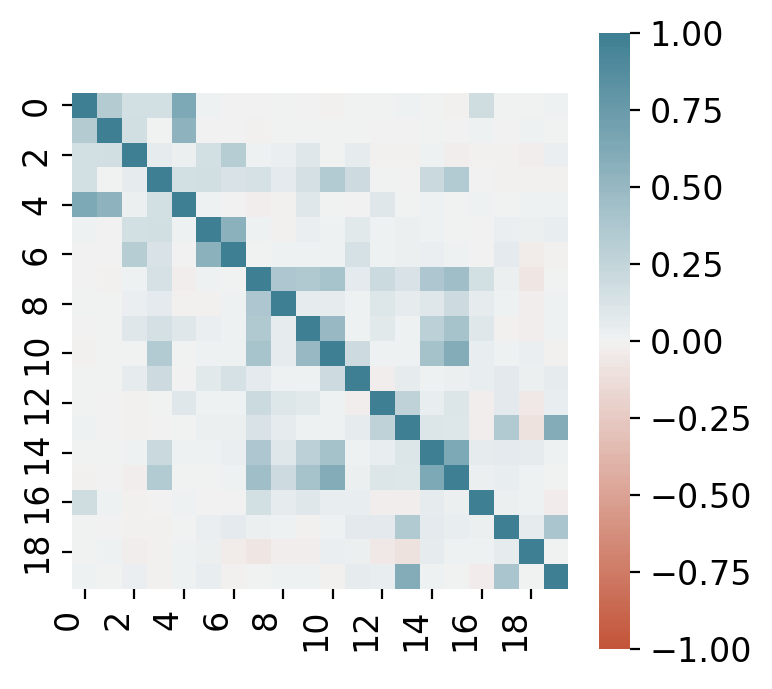

In [ ]:
# Visualicemos la matriz de similitudes de las 20 primeras frases
N=20
plt.figure(figsize = (4,4))
ax = sns.heatmap(
    distancias[:N,:N],
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
);

Vemos que los máximos se producen en la diagonal, con **similitud = 1** de cada frase consigo misma.

Adicionalmente, vemos que hay muchas celdas con **valor cercano a cero**, representan los casos cuando no hay coincidencia de vocabulario entre dos frases.

Aparecen también algunos **valores negativos**, que indican similitud entre vectores con ángulo mayor de 90 grados. Esto es posible porque en la matriz $G$ hay valores tanto positivos como negativos y el ángulo entre vectores puede ser mayor de 90 grados.

Finalmente podemos mostrar la frase más parecida a una dada. Ejecutar varias veces el siguiente código y analizar si el contenido de las dos frases es similar:

In [ ]:
N = len(lista_frases_norm_tokens_string)
cual = random.randint(0, N)

print('-' * 50)
print("Frase aleatoria de referencia:")
print('-' * 50)
print(lista_frases_string[cual])
print('-' * 50)

print('\n' + '-' * 50)
print(f"La frase más parecida es:")
print('-' * 50)
d = np.array(distancias[cual,:])
idx_sim = np.argsort(-d)

for i in range(2):
    if idx_sim[i] != cual:
        print(lista_frases_string[idx_sim[i]])
print('-' * 50)

--------------------------------------------------
Frase aleatoria de referencia:
--------------------------------------------------
It said preliminary results are encouraging and a feasibility
  study is nearing completion.
  


--------------------------------------------------

--------------------------------------------------
La frase más parecida es:
--------------------------------------------------
It said preliminary results are encouraging and a feasibility
  study is nearing completion.
  


--------------------------------------------------


Como vemos el resultado es bastante razonable, pues las dos frases mostradas guardan bastante similitud entre ellas.

## 3.2 - Similitud entre frases basada en word embeddings

Otra opción habitual para codificar un texto corto es utilizar la **media** de los word embeddings asociados a cada una de las palabras. Esta función está [directamente implementada en spaCy](https://spacy.io/usage/linguistic-features) cuando llamamos al método `.similarity` para calcular la similitud entre dos frases.

Spacy proporciona directamente la **medida de similitud** según embedding a partir del formato `Spacy Doc`:

- ``doc1.similarity(doc2)``, donde ``doc1`` y ``doc2`` han de ser de tipo ``Spacy Doc``.

Adicionalmente, Spacy Doc proporciona también el **parámetro ``.vector``**, que representa el **embedding de un texto completo**, y con el cual se pueden realizar medidas de distancia.

In [ ]:
Ndocs = 20
similitudes_embeddings = np.zeros([Ndocs, Ndocs])
for m in tqdm(range(Ndocs)):
  for n in range(Ndocs):
    similitudes_embeddings[m, n] = lista_frases_spacy_doc[m].similarity(lista_frases_spacy_doc[n])


100%|██████████| 20/20 [00:00<00:00, 1532.73it/s]


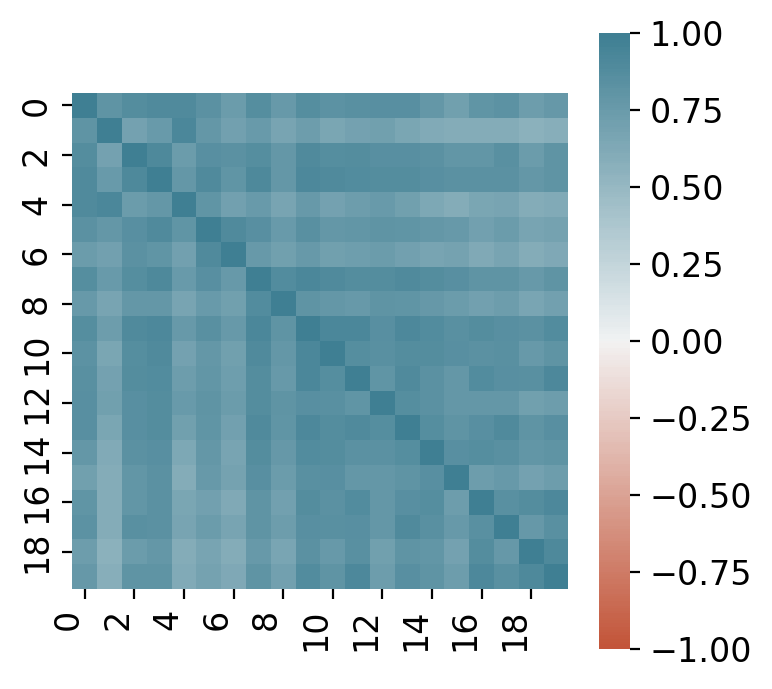

In [ ]:
# Visualicemos la matriz de similitudes de las 50 primeras oraciones
plt.figure(figsize = (4,4))
ax = sns.heatmap(
    similitudes_embeddings[:Ndocs,:Ndocs],
    vmin=-1, vmax=1, center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True
)
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=90,
    horizontalalignment='right'
);

Vemos en este caso que los máximos siguen estando en la diagonal (similitud de cada palabra consigo misma).

Por otro lado, observamos que casi todas las distancias tienen un valor superior a cero, ya que en el espacio del embedding no importa que no estén presentes exactamente las mismas palabras.

Si se considera que hay demasiada cercanía entre frases, se pueden **eliminar los tipos de palabras que aportan poca información**. Por ejemplo, no suele ser significativo que dos frases compartan los mismos determinantes, y sí es importante la comparación de nombres, verbos, etc.

### Ejercicio: frase con mayor similitud

Dada una frase aleatoria, encontrar la frase con mayor similitud en el espacio "Doc embedding".

In [ ]:
N = len(lista_frases_spacy)
cual = random.randint(0, N)

print("Frase de referencia:\n")
print(lista_frases_string[cual])

print(f"\nLa frase más parecida es:\n")

distancias_a_idx = <INSERT CODE HERE>

idx_sim = np.argsort(-distancias_a_idx)

for i in range(2):
    if idx_sim[i] != cual:
        print(lista_frases_string[idx_sim[i]])


### Solución

In [ ]:
N = len(lista_frases_spacy)
cual = random.randint(0, N)

print("Frase de referencia:\n")
print(lista_frases_string[cual])

print(f"\nLa frase más parecida es:\n")

distancias_a_idx = np.array([lista_frases_spacy[cual].similarity(s) for s in lista_frases_spacy])

idx_sim = np.argsort(-distancias_a_idx)

for i in range(2):
    if idx_sim[i] != cual:
        print(lista_frases_string[idx_sim[i]])


Frase de referencia:

Gaviria submitted to the world bank and the inter-american
  bank last week in new york a borrowing plan, for a total of
  3.054 billion dlrs to be disbursed over the next four years,
  which he said was approved.
  



La frase más parecida es:

Kim, who is also economic planning minister, said prospects
  were bright for the South Korean economy, but the government
  would try to hold the current account surplus to around five
  billion dlrs a year for the next five years.
      


Vemos que ahora las similitudes no se restringen únicamente a que aparezca la misma palabra, si aparecen palabras que en el espacio del embedding están próximas, también se consideran de alta similitud, por ejemplo.

### Ejercicio de ampliación: localizando países o ciudades "cercanos"

Localice las palabras del vocabulario que representan **países o ciudades** y busque para cada una de ellas las **tres palabras más cercanas** en el espacio del embedding.

**Nota**: la cercanía a la que nos referimos es lingüística, no geográfica; así, si en los textos aparecen dos países que colaboran mucho económicamente, aparecerán como cercanos en el espacio del embedding.

In [ ]:
paises_y_ciudades = <INSERT CODE HERE>
print("Estos son algunos de los países y ciudades encontrados:")
for lugar in paises_y_ciudades[0:20]:
  print(lugar)

In [ ]:
for palabra_elegida in paises_y_ciudades:
  resultados = find_closest_words(palabra_elegida, embeddings_dict, vocab)
  print("{} -> {}, {}, {}".format(palabra_elegida, resultados[0], resultados[1], resultados[2]))

### Solución

In [ ]:
paises_y_ciudades = [palabra for palabra in vocab if len(nlp(palabra).ents) > 0 and nlp(palabra).ents[0].label_ == "GPE"]
print("Estos son algunos de los países y ciudades encontrados:")
for lugar in paises_y_ciudades[0:20]:
  print(lugar)

Estos son algunos de los países y ciudades encontrados:
thailand
cif
indonesia
malaysia
rotterdam
korea
mexico
taiwan
australia
hong
kong
philippines
america
brazil
canada
china
japan
seoul
washington
alberta


In [ ]:
for palabra_elegida in paises_y_ciudades[0:20]:
  resultados = find_closest_words(palabra_elegida, embeddings_dict, vocab)
  print("{} -> {}, {}, {}".format(palabra_elegida, resultados[0], resultados[1], resultados[2]))

thailand -> asia, singapore, taiwan
cif -> hecla, feedgrains, amselco
indonesia -> indonesian, malaysia, jakarta
malaysia -> singapore, malaysian, kuala
rotterdam -> netherlands, hamburg, belgium
korea -> taiwan, korean, asia
mexico -> mexican, spain, venezuela
taiwan -> korea, hong, singapore
australia -> zealand, australian, canada
hong -> kong, singapore, taiwan
kong -> hong, taiwan, singapore
philippines -> philippine, manila, singapore
america -> american, europe, americans
brazil -> brasil, brazilian, argentina
canada -> canadian, australia, toronto
china -> taiwan, chinese, asia
japan -> japanese, tokyo, asia
seoul -> korea, taiwan, tokyo
washington -> oregon, portland, virginia
alberta -> ontario, vancouver, columbia
